## We are creating an email classification system, the lets you classify your email into 4 categories (spam, important, social and promotions)

In [30]:
# impprting all the required libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import unicodedata # advance text cleaning library

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [31]:
# Load the dataset
df = pd.read_csv("email_classifier_dataset.csv")

In [32]:
# checking the first few rows of the dataset
df.head()

,subject,label
0,Adam Robinson sent you a connection request,Social
1,Your insurance renewal is coming up,Important
2,Last chance to grab these bestsellers,Promotion
3,Your rewards points are about to expire!,Promotion
4,Your wishlist items are on sale now!,Promotion


In [33]:
# check th shape of the dataset
df.shape

(2000, 2)

In [34]:
# check label column
df['label'].value_counts()

label
Important    550
Promotion    550
Social       500
Spam         400
Name: count, dtype: int64

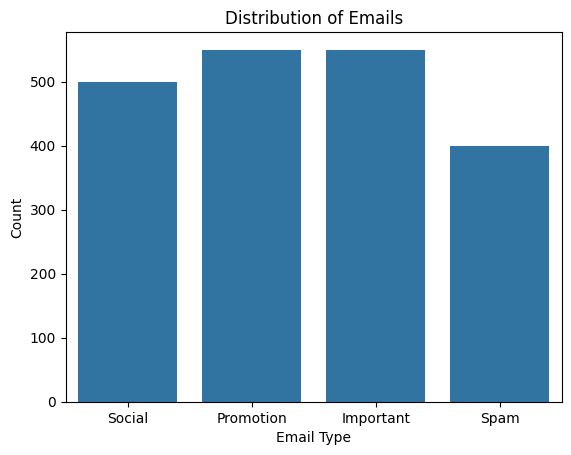

In [35]:
# check the label distribution
sns.countplot(x='label', data=df)
plt.title('Distribution of Emails')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Social','Promotion', 'Important','Spam'])   
plt.show()

In [36]:
# checking for missing values
df.isnull().sum()

subject    0
label      0
dtype: int64

In [37]:
# checking for duplicate values
df.duplicated().sum()

np.int64(1184)

In [38]:
# see the duplicate values
df[df.duplicated()]

,subject,label
20,Last chance to grab these bestsellers,Promotion
22,Last chance to grab these bestsellers,Promotion
25,Your rewards points are about to expire!,Promotion
32,Urgent: Claim your lottery winnings NOW,Spam
34,CONFIDENTIAL: Business proposal from Nigeria,Spam
...,...,...
1990,We miss you – here's 20% off to come back,Promotion
1993,Click here to claim your prize before it expires,Spam
1994,Your wishlist items are on sale now!,Promotion
1997,Make money fast – join our exclusive network,Spam


we have got 1184 dupliacted values in the dataset since the dataset was created using Chatgpt, so the results may also be effected, and it will work very well on real dataset.

In [39]:
# divide the dataset into features and target variable
X = df['subject']
y = df['label']

In [40]:
# apply label encoding to the target variable, and save the mapping, and also save the label encoder for future use
le = LabelEncoder()
y = le.fit_transform(y)
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
    

In [41]:
# now we will start workin on features column.
# we will start with text preprocessing, we will remove special characters, stop words, and lemmatize the words.
# we will also convert the text to lowercase.
def preprocess_text(text):
    """
    Cleans text data by removing noise, stopwords, and applying POS-aware lemmatization.
    """
    # 1. convert to lowercase
    text = text.lower()

    # 2. remove special characters and numbers
    # normalize unicode
    text = unicodedata.normalize('NFKD', text)

    # remove unwanted characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. tokenize the text
    words = text.split()

    # 4. remove stop words
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # 5. POS tagging
    pos_tags = pos_tag(words)

    # 6. lemmatization with POS
    lemmatizer = WordNetLemmatizer()

    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'  # noun (default)

    words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    return ' '.join(words)


In [42]:
# apply the preprocess_text function to the subject column
df['subject'] = df['subject'].apply(preprocess_text)

In [43]:
# check the first few rows of the dataset after preprocessing
df.head()

,subject,label
0,adam robinson send connection request,Social
1,insurance renewal come,Important
2,last chance grab bestseller,Promotion
3,reward point expire,Promotion
4,wishlist item sale,Promotion


In [44]:
# apply tfidf vectorization to the subject column and save the vectorizer for future use
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['subject'])
with open("models/vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [45]:
# apply train test split to the dataset
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# since we will be using multiple models, we will create a function to train and evaluate the models, and save the best model for future use.
def get_models():
    return {
        "Naive Bayes": MultinomialNB(),
        "SVM": SVC(probability=True),
        "Logistic Regression": LogisticRegression(max_iter=200)
    }

In [47]:
# train and evaluate the models, and save the results in a list, and also save the trained models in a dictionary for future use.
def train_and_evaluate(X_train, X_test, y_train, y_test, models):
    results = []
    trained_models = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append([name, acc, prec, rec, f1])
        trained_models[name] = model

        print(f"{name} Done.")

    return results, trained_models


In [48]:
#create the comparison table for the models
def create_results_table(results):
    df_results = pd.DataFrame(results, columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1-score"
    ])

    print("\n=== Model Comparison ===\n")
    print(df_results)

    return df_results

In [49]:
# visualiz the comparison of the models.
def plot_accuracy(df_results):
    plt.figure()
    plt.bar(df_results["Model"], df_results["Accuracy"])
    plt.title("Model Accuracy Comparison")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    plt.show()


In [50]:
# confusion matrix for the best model
def plot_conf_matrix(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [51]:
# creating cross validation function for the best model
from sklearn.model_selection import cross_val_score

def cross_validate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=5)
    return scores.mean()


In [52]:
# adding grid search for hyperparameter tuning of the best model
from sklearn.model_selection import GridSearchCV
def tune_logistic_regression(X_train, y_train):
    param_grid = {
        'C': [0.1, 1, 10]
    }

    grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=3)
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    return grid.best_estimator_


In [53]:
# save the best model for future use using pickle
def save_models(best_model, vectorizer, label_encoder):
    os.makedirs("models", exist_ok=True)

    with open("models/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    with open("models/vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)

    with open("models/label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoder, f)

In [54]:
def run_training_pipeline():

    df = pd.read_csv("email_classifier_dataset.csv")

    #preprocess the data
    X = df['subject'].apply(preprocess_text)
    y = df['label']

    le = LabelEncoder()
    y = le.fit_transform(y)

    os.makedirs("models", exist_ok=True)

    # save label encoder
    with open("models/label_encoder.pkl", "wb") as f:
        pickle.dump(le, f)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=5000)
    X_tfidf = tfidf.fit_transform(X)

    # save vectorizer
    with open("models/vectorizer.pkl", "wb") as f:
        pickle.dump(tfidf, f)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # models
    models = get_models()

    results, trained_models = train_and_evaluate(
        X_train, X_test, y_train, y_test, models
    )

    df_results = create_results_table(results)

    plot_accuracy(df_results)

    # confusion matrix (clean version)
    for name, model in trained_models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    # best model
    best_model_name = df_results.sort_values(
        by="F1-score",
        ascending=False
    ).iloc[0]["Model"]

    best_model = trained_models[best_model_name]

    # save everything properly
    save_models(best_model, tfidf, le)

    print(f"\n🏆 Best Model: {best_model_name}")

In [55]:
# creating a function to predict the email type based on the subject using the best model.
import os

def predict_email(text):

    if not text or text.strip() == "":
        return {"error": "Empty input"}

    if not os.path.exists("models/best_model.pkl"):
        return {"error": "Model not trained yet"}

    model = pickle.load(open("models/best_model.pkl", "rb"))
    vectorizer = pickle.load(open("models/vectorizer.pkl", "rb"))
    label_encoder = pickle.load(open("models/label_encoder.pkl", "rb"))

    clean = preprocess_text(text)
    vec = vectorizer.transform([clean])

    pred = model.predict(vec)[0]

    # confidence (safe & simple)
    if hasattr(model, "predict_proba"):
     proba = model.predict_proba(vec)
     confidence = float(np.max(proba))
    else:
        confidence = None
        confidence = float(np.max(proba))

    label = label_encoder.inverse_transform([pred])[0]

    return {
        "category": label,
        "confidence": confidence
    }


Training Naive Bayes...
Naive Bayes Done.

Training SVM...
SVM Done.

Training Logistic Regression...
Logistic Regression Done.

=== Model Comparison ===

                 Model  Accuracy  Precision  Recall  F1-score
0          Naive Bayes    0.9975   0.997523  0.9975  0.997498
1                  SVM    1.0000   1.000000  1.0000  1.000000
2  Logistic Regression    1.0000   1.000000  1.0000  1.000000


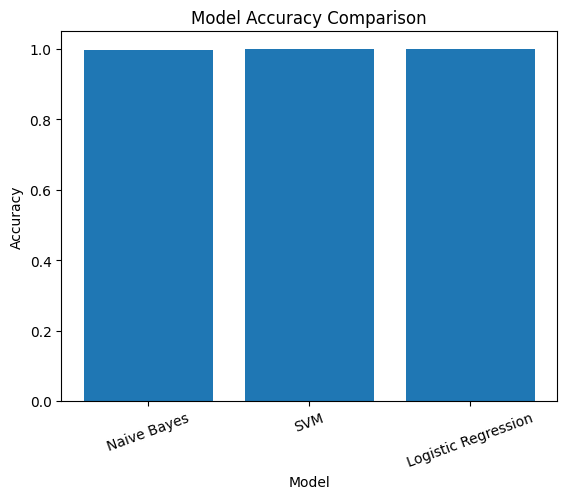

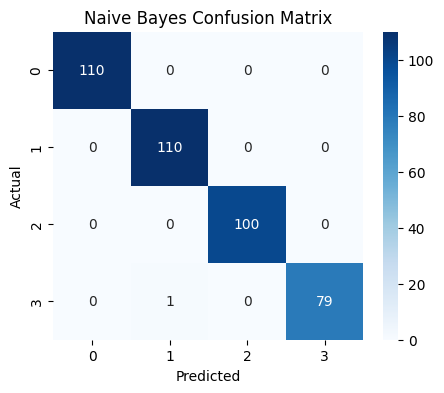

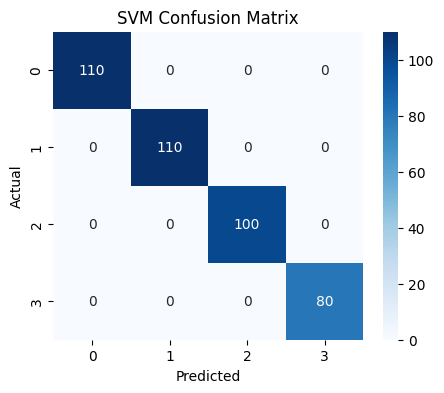

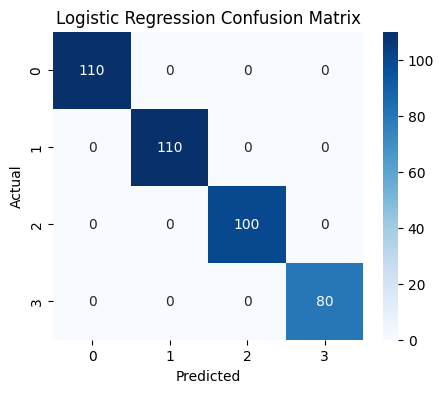


🏆 Best Model: SVM


In [56]:
run_training_pipeline()